## SR25MSAD016

# Imports Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import confusion_matrix

2026-03-25 10:41:32.246469: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-25 10:41:32.247956: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-25 10:41:32.269630: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-25 10:41:32.269652: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-25 10:41:32.270320: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

# Task 1 Data Loading and Visualization

## Load MNIST datase

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

## Print Number Of Sample

In [3]:
print("Number of training samples:", x_train.shape[0])
print("Number of testing samples:", x_test.shape[0])

Number of training samples: 60000
Number of testing samples: 10000


## Print shape of dataset

In [4]:
print("Shape of each image:", x_train.shape[1:])

Shape of each image: (28, 28)


## Print range of pixel values

In [5]:
print("Pixel value range:", np.min(x_train), "to", np.max(x_train))

Pixel value range: 0 to 255


## Display a 4x4 grid of sample images

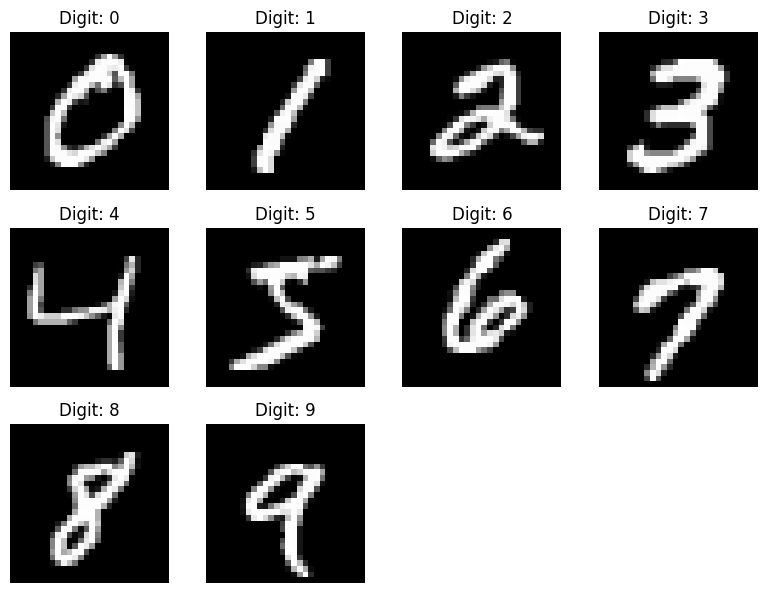

In [6]:
plt.figure(figsize=(8, 8))
for digit in range(10):
    index = np.where(y_train == digit)[0][0]
    
    plt.subplot(4, 4, digit + 1)
    plt.imshow(x_train[index], cmap='gray')
    plt.title(f"Digit: {digit}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Print class distribution (count of each digit in training set)

In [7]:
print("\nClass distribution in training set:")
for digit in range(10):
    count = np.sum(y_train == digit)
    print(f"Digit {digit}: {count} images")


Class distribution in training set:
Digit 0: 5923 images
Digit 1: 6742 images
Digit 2: 5958 images
Digit 3: 6131 images
Digit 4: 5842 images
Digit 5: 5421 images
Digit 6: 5918 images
Digit 7: 6265 images
Digit 8: 5851 images
Digit 9: 5949 images


# Task 2: Data Preprocessing

## Normalize pixel values from [0, 255] → [0, 1]

In [8]:
x_train = x_train / 255.0
x_test = x_test / 255.0

## Resize images (28x28 → 784) for ANN input

In [9]:
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

## Convert labels to one-hot encoding

In [10]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

## Split training data into training and validation (80:20)

In [11]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42
)

## Print shapes to verify

In [12]:
print("Training set shape:", x_train.shape)
print("Validation set shape:", x_val.shape)
print("Test set shape:", x_test.shape)

Training set shape: (48000, 784)
Validation set shape: (12000, 784)
Test set shape: (10000, 784)


## TASK 3: MODEL BUILDING

## Create a Sequential model (layer-by-layer)

In [13]:
model = Sequential()

## Input layer + First hidden layer
## 128 neurons with ReLU activation

In [14]:
model.add(Dense(128, activation='relu', input_shape=(784,)))

## Dropout layer to prevent overfitting

In [15]:
model.add(Dropout(0.3))

## Second hidden layer

In [16]:
model.add(Dense(64, activation='relu'))

## Dropout again

In [17]:
model.add(Dropout(0.3))

## Output layer (10 classes → digits 0–9)
## Softmax converts outputs into probabilities

In [18]:
model.add(Dense(10, activation='softmax'))

## Print model summary

In [19]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               100480    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 10)                650       
                                                                 
Total params: 109386 (427.29 KB)
Trainable params: 109386 (427.29 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## TASK 4: MODEL COMPILATION AND TRAINING

## Compile the model
## Loss: categorical_crossentropy (for multi-class classification)
## Optimizer: Adam (adaptive learning)
## Metric: accuracy

In [20]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

## Train the model
## epochs=100 → number of passes through dataset
## batch_size=128 → samples per gradient update
## validation_data → monitor validation performance

In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=100,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1 
)

Epoch 1/100
375/375 [==============================] - 1s 3ms/step - loss: 0.5686 - accuracy: 0.8267 - val_loss: 0.2032 - val_accuracy: 0.9390
Epoch 2/100
 74/375 [====>.........................] - ETA: 0s - loss: 0.2889 - accuracy: 0.9167

# TASK 5: MODEL EVALUATION AND PLOTTING

## Evaluate model on test data

In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

## Plot accuracy graph

In [ ]:
# Training vs Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()


# Training vs Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

# TASK 6: PREDICTION AND RESULT DISPLAY

## Predict first 10 test images

In [ ]:
predictions = model.predict(x_test[:10])
predicted_labels = np.argmax(predictions, axis=1)
actual_labels = np.argmax(y_test[:10], axis=1)

## Display images with predictions

In [ ]:
plt.figure(figsize=(12, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    
    # Reshape back to 28x28
    img = x_test[i].reshape(28, 28)
    
    plt.imshow(img, cmap='gray')
    plt.title(f"P:{predicted_labels[i]} | A:{actual_labels[i]}")
    plt.axis('off')

plt.show()

## Print actual vs predicted

In [ ]:
print("Actual labels:   ", actual_labels)
print("Predicted labels:", predicted_labels)

## Confusion Matrix for entire test set

In [ ]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
cm

## Plot confusion matrix

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()